In [1]:
import gaussxw as gss
import numpy as np

### Problem 1: Capacidade térmica de um sólido

Ateoria de Debye para sólidos fornece a seguinte expressão para a capacidade térmica de uma
sólido a temperatura $T$,

$$ C_{V} = 9V\rho k_{B} \left( \frac{T}{\theta_{D}} \right)^{3} \int_{0}^{\theta_{D}/T} \frac{x^{4}e^{x}}{(e^{x} - 1)^{2}} dx $$

onde V é o volume do sólido, $\rho$ é a densidade de átomos, $k_{B}$ é a constante de Boltzmann e $\theta_{D}$ é a chamada *temperatura de Debye*, uma propriedade dos sólidos que depende da sua densidade e da velocidade do som.

a) Escreva uma função cv(T) que calcula $C_{V}$ para um dado valor de temperatura, para uma amostra consistindo de $1000cm^{3}$ de alumínio sólido, que tem uma densidade de $\rho = 6.022 \times 10^{28}m^{-3}$ e uma temperatura de Debye de $\theta_{D} = 428K$. Use a quadratura Gaussiana para calcular o valor da integral, com $N = 50$ pontos. (Dica: para $T = 100K$, $C_{V}$ ~ $1100J/K$).

In [2]:
p_d = 6.022e28
theta = 428
V = 1e-3
k_b = 1.38e-23
N = 50

T0 = 100
a0, b0 = 0, theta/T0

In [3]:
def func1(x):
    num, den = (x**4)*np.exp(x), ((np.exp(x)) - 1)**2
    return num/den

In [4]:
def cv_integral(a, b, N, T):

    x, w = gss.gaussxw(N)
    
    xp = 0.5*(b-a)*x + 0.5*(b+a)
    wp = 0.5*(b-a)*w
    
    s = 0.0
    for k in range(N):
        s += wp[k]*func1(xp[k])

    return s

In [5]:
const0 = 9 * V * p_d * k_b * (T0/theta)**3
cv = const0 * cv_integral(a0, b0, N, T0)

In [6]:
print(f'Cv ~ {cv}')

Cv ~ 1152.7216478493665


b) Use sua funçao para fazer um gráfico do calor específico como uma função da temperatura de $T = 5K$ até $T = 500K$.

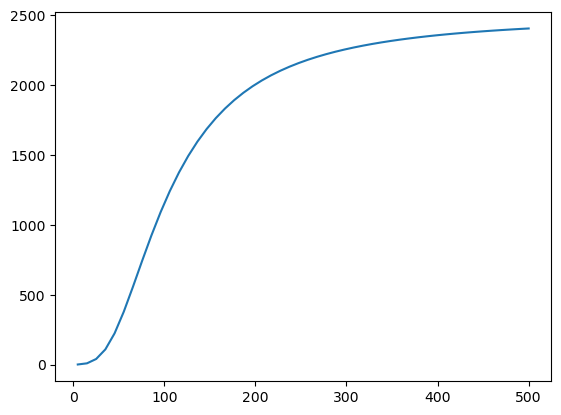

In [7]:
import matplotlib.pyplot as plt

Ts = np.linspace(5, 500, 50)
all_cvs = []

for T in Ts:
    const = 9 * V * p_d * k_b * (T/theta)**3
    a, b = 0, theta/T
    all_cvs.append(const * cv_integral(a, b, N, T))

plt.plot(Ts, all_cvs)
plt.show()

### Problem 2: A constante de Stefan-Boltzmann

Ateoria da radiacção térmica de Planck nos diz que no intervalo de frequência angular $\omega$ até
$\omega + d\omega$, um corpo negro com área unitária emite radiação eletromagnética com uma energia
térmica por segundo igual a $I(\omega)d\omega$, onde

$$ I(\omega) = \frac{\hslash}{4\pi^{2}c^{2}} \frac{\omega^{3}}{(e^{\hslash \omega/k_{B}T} - 1)}.$$

Aqui $\hslash$ é a constante de Planck sobre $2\pi$, $c$ é a velocidade da luz e $k_{B}$ é a constante de Boltzmann.

a) Mostre que a energia total irradiada por unidade de área de um corpo negro ´e dada por
(Dica: integre a express˜ao acima por todas as frequˆencias angulares)

$$ W = \frac{k_{B}^{4}T^{4}}{4\pi^{2}c^{2}\hslash^{3}} \int_{0}^{\infty} \frac{x^{3}}{e^{3} - 1} dx.$$

**Integrating the first equation we have**

$$\int I(\omega) d\omega = \int \frac{\hslash}{4\pi^{2}c^{2}} \frac{\omega^{3}}{(e^{\frac{\hslash \omega}{k_{B}T}}-1)} d\omega$$

**Making the substitution:**
$$x = \frac{\hslash \omega}{k_{B}T}  \rightarrow dx= \frac{\hslash}{k_{B}T} d\omega,\ \ \ \ \ \ temos\ \ \ \ \ \omega^{3} = \frac{x^{3}k_{B}^{3} T^{3}}{\hslash^{3}}\ \ e\ \ d\omega = \frac{k_{B}T}{\hslash} dx$$

**Where we arrive at the expected result simply by substituting these values ​​into the integral:**
$$W = \int_{0}^{\infty} I(\omega)d\omega = \frac{\hslash}{4\pi^{2}c^{2}} \int_{0}^{\infty} \frac{\frac{x^{3}k_{B}^{3} T^{3}}{\hslash^{3}}}{(e^x-1)}$$

$$\therefore\  \boxed{W =\frac{k_{B}^{4}T^{4}}{4\pi^{2}c^{2}\hslash^{3}} \int_{0}^{\infty} \frac{x^{3}}{(e^{x}-1)}dx}$$

b) Escreva um programa que calcula a integral nessa expressão. Explique qual método você usou e quão preciso é o seu método.

In [8]:
kb = 1.38e-23     # m2 Kg/ s2 K
c = 3e8           # m/ s
h = 6.626e-34     # m2 Kg/ s
h_ = h/(2*np.pi)
T = 100

In [9]:
def const(T):
  nom, den = (kb**4)*T**4, 4*(np.pi**2)*(c**2)*(h_**3)
  return nom/den

def f(y):
  x = (1/y)-1
  nom = x**3
  den = np.exp(x)-1
  return (nom/den)*(1/(y**2))

def integ_simp(a, b, h, N):
  soma = 0

  for k in range(1, N):
    if k%2 != 0:
      soma += 4*f(a+k*h)
    else:
      soma += 2*f(a+k*h)
  i_simp = (h/3)*(f(a) + f(b) + soma)
  return i_simp

In [10]:
kb = 1.38e-23     # m2 Kg/ s2 K
c = 3e8           # m/ s
h = 6.626e-34     # m2 Kg/ s
h_ = h/(2*np.pi)
T = 100

N = 1000
a, b = 0.05, 1.02
h = (b-a)/N

W = const(T)*integ_simp(a, b, h, N)

print(f'W: {W:.4f} J/m²')

W: 5.6520 J/m²


c) Mesmo antes de Planck introduzir sua teoria de radiação, em torno da virada do século XX, era conhecido que $W$ é dado pela Lei de Stefan: $W = \sigma T^4$, onde $\sigma$ é a constante de Stefan–Boltzmann. Utilize o valor da integral calculado no item anterior para estimar o valor da constante de Stefan–Boltzmann (em unidades do SI) com três dígitos significativos. Compare seu resultado com o valor conhecido e verifique se o resultado é satisfatório. (Dica: a integral a ser calculada vale aproximadamente $6,5$).

In [11]:
W2 = const(T)*integ_simp(a, b, h, 2*N)

e2 = (1/3)*(W2-W)
print(f'erro e2: {100*abs(e2):.2f}%')

erro e2: 1.43%


In [12]:
cst_stf_btz = W/(T**4)

print(f'const stefan_boltzman: {cst_stf_btz*1e8:.3f} Kg/s3K4')

const stefan_boltzman: 5.652 Kg/s3K4


The true value is $\sigma = 5.6704 \cdot 10^{-8} W m^{-2} K^{-4}$

### Problem 3: Atração gravitacional de uma folha uniforme

Uma folha quadrada uniforme de metal está flutuando sem se mover no espaço. A folha tem $10\text{ m}$ de lado e espessura desprezível. A sua massa é de $10$ toneladas.

a) Considere a força gravitacional devido à placa sentida por um ponto de massa $1\text{ kg}$, situado a uma distância $z$ do centro do quadrado, em uma direção perpendicular à folha, como mostrado acima. Mostre que a componente da força ao longo do eixo $z$ é:

**By dividing the plate into n small squares, we can calculate the force on each square individually and integrate over the entire plate. We can see that the components of each force parallel to the plane cancel each other out (body aligned with the center of the plate), so only the vertical component (z-axis) would act on the particle, attracting it towards the plate.**

$$dF_{g} = \frac{G\ m\ dM}{r^{2}}cos(\theta) = \frac{G\ m\ dM}{(z^{2}+x^{2}+y^{2})}cos(\theta)$$

**using that:**
$$cos(\theta) = \frac{z}{(z^{2}+x^{2}+y^{2})^{1/2}}\ \ \ e\ \ \ d
M= \sigma \ dxdy$$

**we have:**
$$dF_{square} = \frac{G\ m\ z\ \sigma \ dxdy}{(z^{2}+x^{2}+y^{2})^{3/2}}$$

**Since the plate is symmetrical along the x and y axes, we can multiply the integral by 4 and integrate with respect to dx and dy:**
$$4\ \int_{F(0)}^{F_{g}(L/2)} dF_{square} = F_{total} = 4G\ m\ z\ \sigma\ \int_{0}^{L/2}\int_{0}^{L/2} \frac{dxdy}{(z^{2}+x^{2}+y^{2})^{3/2}}$$

**so:**
$$\therefore\  \boxed{F_{z} = 4G\ m\ z\ \sigma\ \int_{0}^{L/2}\int_{0}^{L/2} \frac{dxdy}{(z^{2}+x^{2}+y^{2})^{3/2}}}$$

b) Escreva um programa para calcular e plotar a força em função de $z$, de $z = 0$ até $z = 10\text{ m}$. Para a integral dupla, use (dupla) quadratura gaussiana, seguindo a Eq. (5.82), com $100$ pontos de amostra ao longo de cada eixo.

In [13]:
# import intinf
# from intinf import *

G = 6.674e-11       # m3/ kg s2
sig = 100           # Kg/ m2

L = 10
a, b = 0, L/2
N = 100

In [14]:
def func(x, y, z):
    return 1/((x**2)+(y**2)+(z**2))**3/2
        
def forca(z):
    x, wx = gss.gaussxwab(N, a, b)
    
    y = ((b-a)/2)*x + (b+a)/2             # arrumar os limites para -1 a 1
    wy = ((b-a)/2)*wx + (b+a)/2           # wy deve mudar igual y

    sum = 0
    for i in range(N):
        for j in range(N):
            sum += wx[i]*wy[j]*func(x[i], y[j], z)
    return 4*sum

In [15]:
zs = np.linspace(0, 10, 100)

forcas = []

for z in zs:
    forcas.append(forca(z))

In [16]:
forcas[:5]

[np.float64(0.37099147311451913),
 np.float64(0.36974822786977307),
 np.float64(0.3660550400330032),
 np.float64(0.36001920052575453),
 np.float64(0.35181194625278994)]

c) Você deve encontrar uma curva suave, exceto para valores bem pequenos de $z$, onde a força deve cair repentinamente para zero. Esta queda não é um efeito real, mas um artefato do modo como foi feito o cálculo. Explique brevemente de onde vem este artefato e sugira uma estratégia para resolvê-lo, ou pelo menos reduzir seu tamanho. (Dica: nas condições dadas, você deve obter um gráfico similar ao mostrado abaixo).

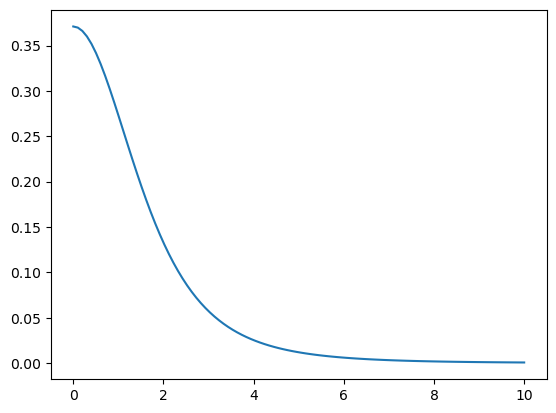

In [17]:
import matplotlib.pyplot as plt

plt.plot(zs, forcas)